In [7]:
# src/etl.py
import pandas as pd
import numpy as np
from pathlib import Path



try:
    # when running as script
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # when running in Jupyter, go one level up from src/
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data_raw"
OUT_DIR = PROJECT_ROOT / "data_curated"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. load the main covid file
covid = pd.read_csv(DATA_DIR / "covid_19_india.csv", parse_dates=["Date"])
# inspect columns
print("covid columns:", covid.columns.tolist())

# Standardize state column name (example uses 'State' or 'State/UnionTerritory')
if 'State/UnionTerritory' in covid.columns:
    covid = covid.rename(columns={'State/UnionTerritory': 'state'})
elif 'State' in covid.columns:
    covid = covid.rename(columns={'State': 'state'})

# Ensure Date column is datetime
covid['Date'] = pd.to_datetime(covid['Date']).dt.normalize()

# 2. load vaccines
vax = pd.read_csv(DATA_DIR / "covid_vaccine_statewise.csv", parse_dates=["Updated On"])
vax = vax.rename(columns={'Updated On':'Date','State':'state'})
vax['Date'] = pd.to_datetime(vax['Date']).dt.normalize()

# pick a vaccine metric - total doses till date or daily doses
if 'Total Doses' in vax.columns:
    vax['total_vaccinated'] = pd.to_numeric(vax['Total Doses'], errors='coerce')
elif 'Totals' in vax.columns:
    vax['total_vaccinated'] = pd.to_numeric(vax['Totals'], errors='coerce')
else:
    # find any numeric column
    numcols = vax.select_dtypes('number').columns
    vax['total_vaccinated'] = vax[numcols[0]] if len(numcols) else 0

# 3. load testing details
tests = pd.read_csv(DATA_DIR / "StateWiseTestingDetails.csv", parse_dates=["Date"])
# adapt column names
for col in tests.columns:
    if col.lower().strip() in ['state', 'state/ut']:
        tests = tests.rename(columns={col: 'state'})
# unify date
if 'Date' in tests.columns:
    tests['Date'] = pd.to_datetime(tests['Date']).dt.normalize()

# 4. create daily panel combining all three sources - per state/day
# choose a canonical list of state names that appear in covid; use them
states = sorted(covid['state'].unique())

# build base panel
date_range = pd.date_range(covid['Date'].min(), covid['Date'].max(), freq='D')
panel = pd.MultiIndex.from_product([states, date_range], names=['state','Date']).to_frame(index=False)

# merge counts from covid
cov_counts = covid.groupby(['state','Date'])[['Confirmed','Recovered','Deaths']].sum().reset_index()
# if column names differ, try 'Confirmed'/'ConfirmedCases' etc.
if 'Confirmed' not in cov_counts.columns:
    # heuristic: find numeric columns that likely correspond
    print("Check covid columns - adapt code to your CSV")
panel = panel.merge(cov_counts, on=['state','Date'], how='left').fillna(0)

# merge vaccines and tests by state/date
panel = panel.merge(vax[['state','Date','total_vaccinated']], on=['state','Date'], how='left')
panel = panel.merge(tests[['state','Date','TotalSamples']], on=['state','Date'], how='left', suffixes=('','_tests'))
panel = panel.fillna(0)

# 5. compute derived fields
# cumulative -> daily new can be computed by group diff
panel = panel.sort_values(['state','Date'])
panel['confirmed_cum'] = panel.groupby('state')['Confirmed'].cumsum()  # if these are daily, else adapt
# compute active = confirmed - recovered - deaths
panel['active'] = panel['Confirmed'] - panel['Recovered'] - panel['Deaths']
# make sure no negative
panel['active'] = panel['active'].clip(lower=0)

# compute daily new if original file was cumulative; otherwise adapt
panel['new_confirmed'] = panel.groupby('state')['Confirmed'].diff().fillna(panel['Confirmed'])
panel['new_recovered'] = panel.groupby('state')['Recovered'].diff().fillna(panel['Recovered'])
panel['new_deaths'] = panel.groupby('state')['Deaths'].diff().fillna(panel['Deaths'])

# 6. population info: if your csv contains population in any column, merge; else use external mapping file
# For now create a placeholder population per state or ask user to provide mapping
if 'Population' in panel.columns:
    panel['population'] = panel['Population']
else:
    # placeholder: set 1M for each state -- replace with real mapping
    pop_map = {s: 1_000_000 for s in states}
    panel['population'] = panel['state'].map(pop_map)

# compute S,I,R
panel['I'] = panel['active']
panel['R'] = panel['Recovered']
panel['S'] = panel['population'] - panel['I'] - panel['R']
panel['S'] = panel['S'].clip(lower=0)

# save curated
panel.to_csv(OUT_DIR / "panel_state_daily.csv", index=False)
print("Saved panel to", OUT_DIR / "panel_state_daily.csv")


covid columns: ['Sno', 'Date', 'Time', 'State/UnionTerritory', 'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured', 'Deaths', 'Confirmed']


C:\Users\dedee\AppData\Local\Temp\ipykernel_20292\2605579450.py:34: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  vax = pd.read_csv(DATA_DIR / "covid_vaccine_statewise.csv", parse_dates=["Updated On"])


KeyError: "Columns not found: 'Recovered'"

In [11]:
# src/etl.py
import pandas as pd
import numpy as np
from pathlib import Path

try:
    # when running as script
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # when running in Jupyter, go one level up from src/
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data_raw"
OUT_DIR = PROJECT_ROOT / "data_curated"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. load the main covid file
covid = pd.read_csv(DATA_DIR / "covid_19_india.csv", parse_dates=["Date"])
print("covid columns:", covid.columns.tolist())

# Standardize state column name
if 'State/UnionTerritory' in covid.columns:
    covid = covid.rename(columns={'State/UnionTerritory': 'state'})
elif 'State' in covid.columns:
    covid = covid.rename(columns={'State': 'state'})

# Rename "Cured" -> "Recovered" for consistency
if "Cured" in covid.columns:
    covid = covid.rename(columns={"Cured": "Recovered"})

# Ensure Date column is datetime
covid['Date'] = pd.to_datetime(covid['Date']).dt.normalize()

# 2. load vaccines
vax = pd.read_csv(DATA_DIR / "covid_vaccine_statewise.csv", parse_dates=["Updated On"], dayfirst=True)
vax = vax.rename(columns={'Updated On':'Date','State':'state'})
vax['Date'] = pd.to_datetime(vax['Date']).dt.normalize()

# pick a vaccine metric
if 'Total Doses' in vax.columns:
    vax['total_vaccinated'] = pd.to_numeric(vax['Total Doses'], errors='coerce')
elif 'Totals' in vax.columns:
    vax['total_vaccinated'] = pd.to_numeric(vax['Totals'], errors='coerce')
else:
    numcols = vax.select_dtypes('number').columns
    vax['total_vaccinated'] = vax[numcols[0]] if len(numcols) else 0

# 3. load testing details
tests = pd.read_csv(DATA_DIR / "StateWiseTestingDetails.csv", parse_dates=["Date"])
for col in tests.columns:
    if col.lower().strip() in ['state', 'state/ut']:
        tests = tests.rename(columns={col: 'state'})
if 'Date' in tests.columns:
    tests['Date'] = pd.to_datetime(tests['Date']).dt.normalize()

# 4. create daily panel combining all three sources
states = sorted(covid['state'].unique())
date_range = pd.date_range(covid['Date'].min(), covid['Date'].max(), freq='D')
panel = pd.MultiIndex.from_product([states, date_range], names=['state','Date']).to_frame(index=False)

# merge counts from covid
cov_counts = covid.groupby(['state','Date'])[['Confirmed','Recovered','Deaths']].sum().reset_index()
panel = panel.merge(cov_counts, on=['state','Date'], how='left').fillna(0)

# merge vaccines and tests
panel = panel.merge(vax[['state','Date','total_vaccinated']], on=['state','Date'], how='left')
panel = panel.merge(tests[['state','Date','TotalSamples']], on=['state','Date'], how='left', suffixes=('','_tests'))
panel = panel.fillna(0)

# 5. compute derived fields
panel = panel.sort_values(['state','Date'])
panel['confirmed_cum'] = panel.groupby('state')['Confirmed'].cumsum()

panel['active'] = panel['Confirmed'] - panel['Recovered'] - panel['Deaths']
panel['active'] = panel['active'].clip(lower=0)

panel['new_confirmed'] = panel.groupby('state')['Confirmed'].diff().fillna(panel['Confirmed'])
panel['new_recovered'] = panel.groupby('state')['Recovered'].diff().fillna(panel['Recovered'])
panel['new_deaths'] = panel.groupby('state')['Deaths'].diff().fillna(panel['Deaths'])

# 6. population info placeholder
if 'Population' in panel.columns:
    panel['population'] = panel['Population']
else:
    pop_map = {s: 1_000_000 for s in states}
    panel['population'] = panel['state'].map(pop_map)

# compute S,I,R
panel['I'] = panel['active']
panel['R'] = panel['Recovered']
panel['S'] = panel['population'] - panel['I'] - panel['R']
panel['S'] = panel['S'].clip(lower=0)

# save curated
panel.to_csv(OUT_DIR / "panel_state_daily.csv", index=False)
print("Saved panel to", OUT_DIR / "panel_state_daily.csv")


covid columns: ['Sno', 'Date', 'Time', 'State/UnionTerritory', 'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured', 'Deaths', 'Confirmed']
Saved panel to C:\Users\dedee\Downloads\epidemic-project\data_curated\panel_state_daily.csv


In [17]:
print("\nSample output (first 10 rows):")
panel.head(100)


Sample output (first 10 rows):


,state,Date,Confirmed,Recovered,Deaths,total_vaccinated,TotalSamples,confirmed_cum,active,new_confirmed,new_recovered,new_deaths,population,I,R,S
0,Andaman and Nicobar Islands,2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000,0.0,0.0,1000000.0
1,Andaman and Nicobar Islands,2020-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000,0.0,0.0,1000000.0
2,Andaman and Nicobar Islands,2020-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000,0.0,0.0,1000000.0
3,Andaman and Nicobar Islands,2020-02-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000,0.0,0.0,1000000.0
4,Andaman and Nicobar Islands,2020-02-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000,0.0,0.0,1000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Andaman and Nicobar Islands,2020-05-04,33.0,32.0,0.0,0.0,0.0,653.0,1.0,0.0,15.0,0.0,1000000,1.0,32.0,999967.0
96,Andaman and Nicobar Islands,2020-05-05,33.0,32.0,0.0,0.0,0.0,686.0,1.0,0.0,0.0,0.0,1000000,1.0,32.0,999967.0
97,Andaman and Nicobar Islands,2020-05-06,33.0,32.0,0.0,0.0,0.0,719.0,1.0,0.0,0.0,0.0,1000000,1.0,32.0,999967.0
98,Andaman and Nicobar Islands,2020-05-07,33.0,32.0,0.0,0.0,0.0,752.0,1.0,0.0,0.0,0.0,1000000,1.0,32.0,999967.0


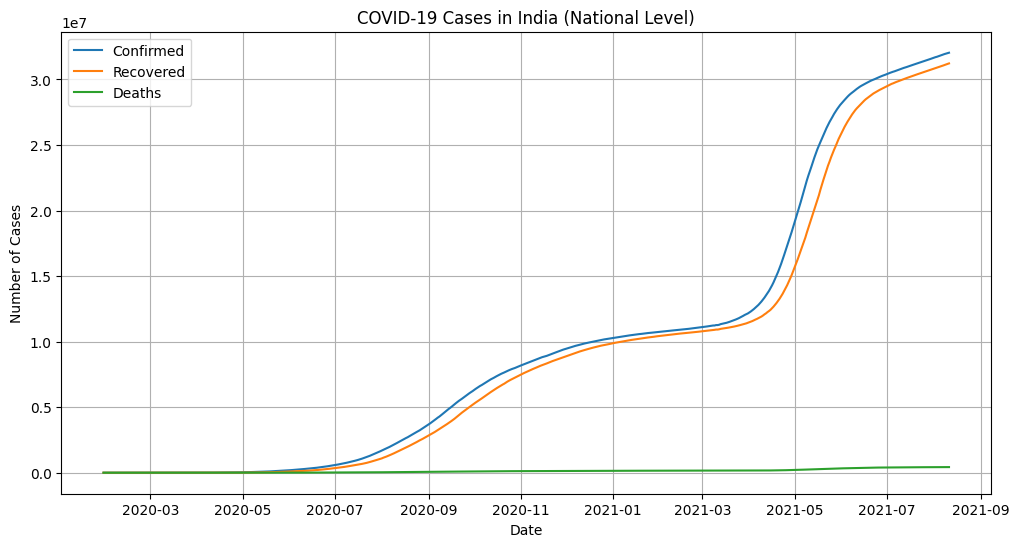

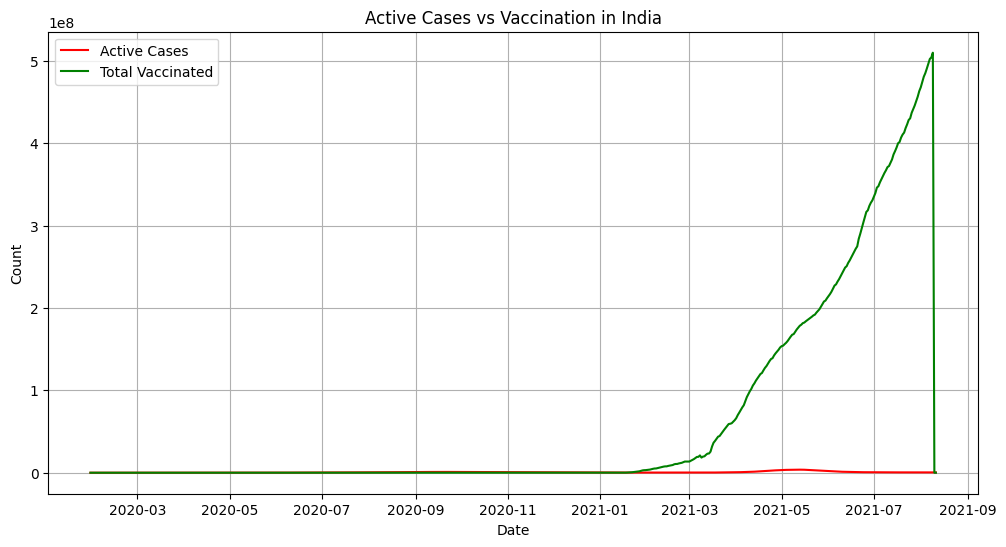

In [18]:
import matplotlib.pyplot as plt
df_national = panel.groupby("Date")[["Confirmed","Recovered","Deaths","active","total_vaccinated"]].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(df_national['Date'], df_national['Confirmed'], label="Confirmed")
plt.plot(df_national['Date'], df_national['Recovered'], label="Recovered")
plt.plot(df_national['Date'], df_national['Deaths'], label="Deaths")
plt.title("COVID-19 Cases in India (National Level)")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_national['Date'], df_national['active'], label="Active Cases", color='red')
plt.plot(df_national['Date'], df_national['total_vaccinated'], label="Total Vaccinated", color='green')
plt.title("Active Cases vs Vaccination in India")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()